<a href="https://colab.research.google.com/github/h1baq1m/skills-getting-started-with-github-copilot/blob/main/Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

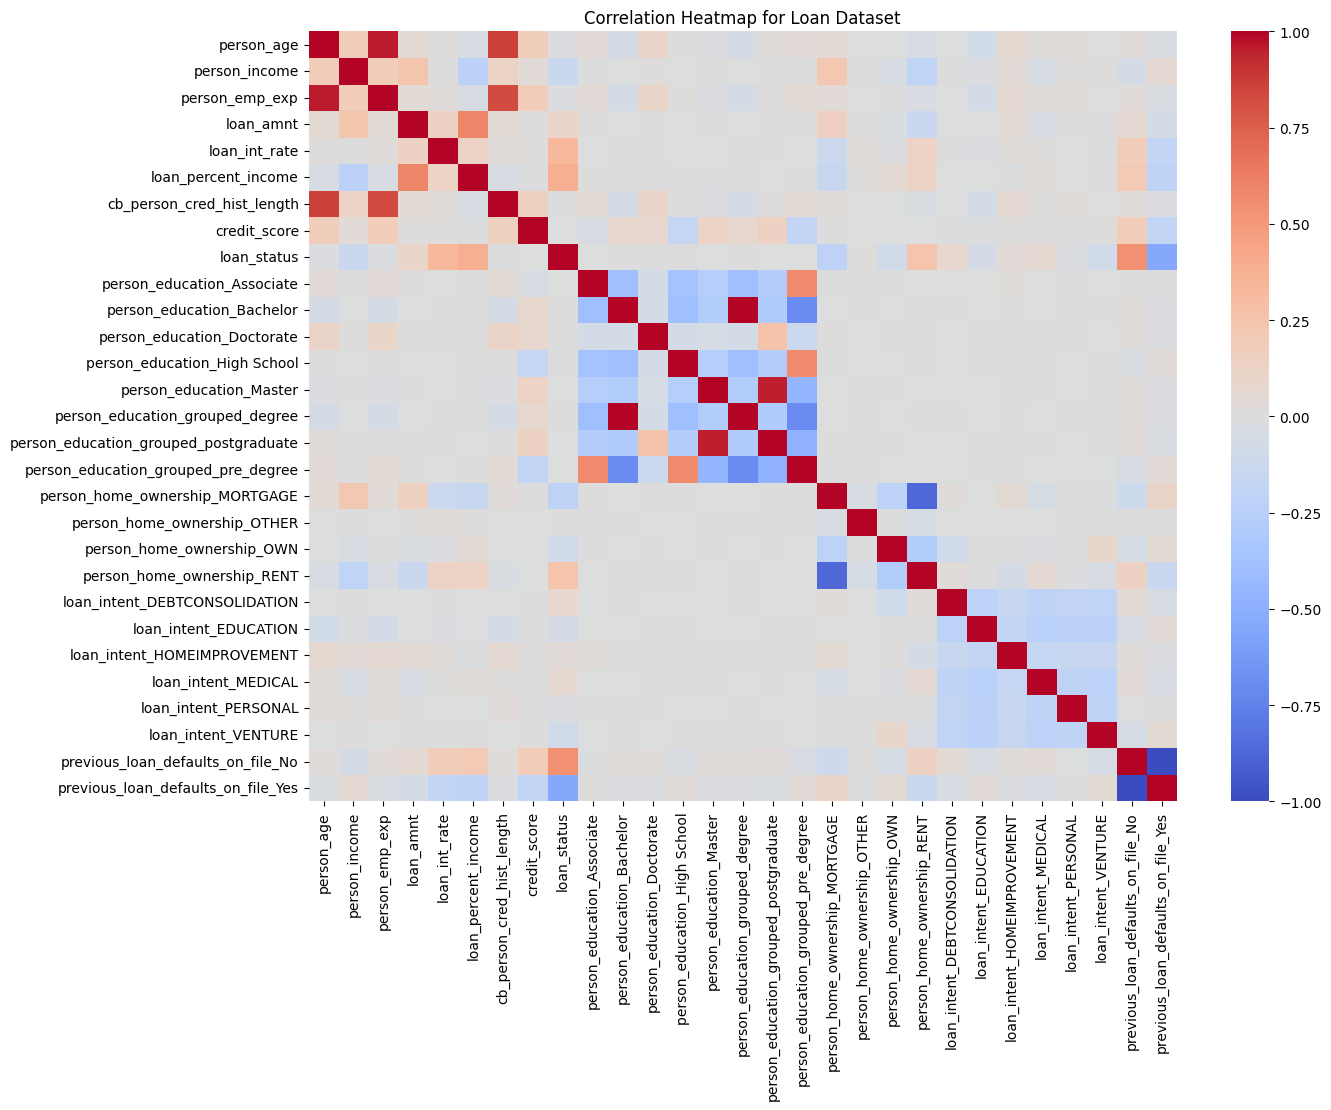

                     loan_percent_income  loan_int_rate  person_income  \
loan_percent_income             1.000000       0.125209      -0.234177   
loan_int_rate                   0.125209       1.000000       0.001510   
person_income                  -0.234177       0.001510       1.000000   
loan_amnt                       0.593011       0.146093       0.242290   
credit_score                   -0.011483       0.011498       0.035919   
loan_status                     0.384880       0.332005      -0.135808   

                     loan_amnt  credit_score  loan_status  
loan_percent_income   0.593011     -0.011483     0.384880  
loan_int_rate         0.146093      0.011498     0.332005  
person_income         0.242290      0.035919    -0.135808  
loan_amnt             1.000000      0.009074     0.107714  
credit_score          0.009074      1.000000    -0.007647  
loan_status           0.107714     -0.007647     1.000000  
Index(['person_age', 'person_income', 'person_emp_exp', 'loan

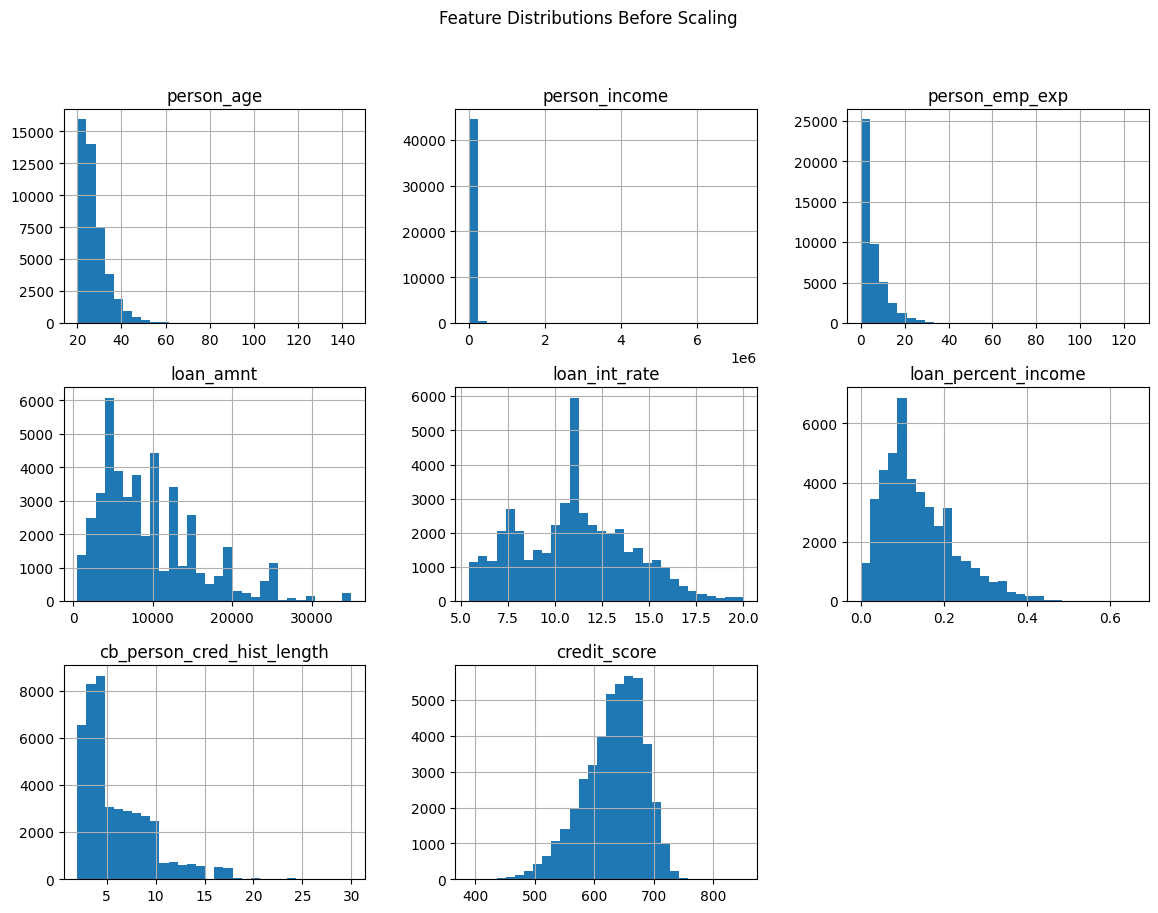

LogisticRegression
Accuracy: 0.8990222222222222
[[8252  498]
 [ 638 1862]]
################
SVC
Accuracy: 0.912
[[8407  343]
 [ 647 1853]]
################
MLPClassifier
Accuracy: 0.9205333333333333
[[8410  340]
 [ 554 1946]]
################


In [11]:
# reads loan_data.csv file and coverts it into a pandas dataframe

import pandas as pd

df = pd.read_csv("loan_data.csv")

# show...

print(df.info())

# show first 10 columns

print(df.head())

# drops any columns not needed within column - gender

df = df.drop(["person_gender"], axis=1)
print(df.info())

# check to see if we have any missing values

print(df.isnull().sum())

# checks how many records would be lost if any missing values were to be dropped

new_df = df.dropna()
print("################")
print("Total records that would be lost if deleted:")
print(df.shape[0] - new_df.shape[0])
del new_df

# checks the value count for each categorical column

categorical_columns = [
    "person_education",
    "person_home_ownership",
    "loan_intent",
    "previous_loan_defaults_on_file"
]

for column in categorical_columns:
    print("################")
    print(column)
    print(df[column].value_counts())

    #grouped education levels within the csv file into broader qualification levels

    education_groups = {
    "High School": "pre_degree",
    "Associate": "pre_degree",
    "Bachelor": "degree",
    "Master": "postgraduate",
    "Doctorate": "postgraduate"

}

df["person_education_grouped"] = df["person_education"].replace(education_groups)
print(df["person_education_grouped"].value_counts())

#drops any missing values

df = df.dropna()
print(df.shape)

# encodes the categorical columns by using the pd.get_dummies() method

df.info()

features_to_encode = [
    "person_education",
    "person_education_grouped",
    "person_home_ownership",
    "loan_intent",
    "previous_loan_defaults_on_file"
]

new_features = pd.get_dummies(df[features_to_encode], drop_first=False, dtype=int)
df = pd.concat([df.reset_index(drop=True), new_features.reset_index(drop=True)], axis=1)
df = df.drop(features_to_encode, axis=1)
df.head(2)

# the label column already exists as 0 and 1 - so checks label column to ensure this

df["loan_status"] = df["loan_status"].astype(int)
print(df["loan_status"].value_counts())
print(df.head())

# feature selection using correlation

#checks how strongly correlated every numeric feature is to loan_status

import seaborn as sns
import matplotlib.pyplot as plt

correlation_matrix = df.corr(numeric_only=True)

print("Correlation with loan_status:")
print(correlation_matrix["loan_status"].sort_values(ascending=False))

plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap for Loan Dataset")
plt.show()

# Focus on some key loan-related variables.
print(df[["loan_percent_income", "loan_int_rate", "person_income", "loan_amnt", "credit_score", "loan_status"]].corr())

# removes the label column from the dataframe and puts it into a separate dataframe

label_df = df["loan_status"]
features = df.drop("loan_status", axis=1)
print(features.columns)

# scale the data

numeric_features = [
    "person_age",
    "person_income",
    "person_emp_exp",
    "loan_amnt",
    "loan_int_rate",
    "loan_percent_income",
    "cb_person_cred_hist_length",
    "credit_score"
]

# Using a histogram to ifentify the distribution of each feature before scaling

df[numeric_features].hist(figsize=(14, 10), bins=30)
plt.suptitle("Feature Distributions Before Scaling")
plt.show()

from sklearn.preprocessing import MinMaxScaler

#scale data

scaler = MinMaxScaler()
scaler.fit(features)
scaled_df = scaler.transform(features)
scaled_df = pd.DataFrame(scaled_df, columns=features.columns)
scaled_df.head(5)


from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

#split the data

X_train, X_test, y_train, y_test = train_test_split(
    scaled_df,
    label_df,
    test_size=0.25,
    random_state=42,
    stratify=label_df

)

#train and test logistic regression, SVM and neural network algorithms

classifiers = [
    LogisticRegression(max_iter=1000, random_state=42),
    svm.SVC(gamma="scale"),
    MLPClassifier(max_iter=1000, random_state=42)
]

for clf in classifiers:
    clf.fit(X_train, y_train)
    name = clf.__class__.__name__
    print(name)

    prediction = clf.predict(X_test)

    acc = accuracy_score(y_test, prediction)
    print("Accuracy:", acc)

    matrix = confusion_matrix(y_test, prediction)
    print(matrix)
    print("################")
